<a href="https://colab.research.google.com/github/IssarapongB/Data-science/blob/main/%E0%B8%9B%E0%B8%A3%E0%B8%B0%E0%B8%AA%E0%B8%9E%E0%B8%81%E0%B8%B2%E0%B8%A3%E0%B8%93%E0%B9%8C%E0%B8%A7%E0%B8%B4%E0%B8%8A%E0%B8%B2%E0%B8%8A%E0%B8%B5%E0%B8%9E_2_68_ipynb_Loan_Status.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Phase 1: Data Preparation using uploaded train & test CSV files

import pandas as pd

# Step 1: Load uploaded files
train = pd.read_csv('/content/drive/MyDrive/ประสพการณ์วิชาชีพ/train.csv')
test = pd.read_csv('/content/drive/MyDrive/ประสพการณ์วิชาชีพ/test.csv')

train

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
train

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
import numpy as np

# Save test Loan_ID for submission later
test_ids = test['Loan_ID']

# Step 2: Drop Loan_ID from both
train.drop('Loan_ID', axis=1, inplace=True)
test.drop('Loan_ID', axis=1, inplace=True)

# Step 3: Add 'Loan_Status' to test set temporarily (to concatenate and process together)
test['Loan_Status'] = np.nan

# Step 4: Combine for consistent preprocessing
combined = pd.concat([train, test], axis=0, ignore_index=True)

combined


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
976,Male,Yes,3+,Not Graduate,Yes,4009,1777.0,113.0,360.0,1.0,Urban,NaN
977,Male,Yes,0,Graduate,No,4158,709.0,115.0,360.0,1.0,Urban,NaN
978,Male,No,0,Graduate,No,3250,1993.0,126.0,360.0,NaN,Semiurban,NaN
979,Male,Yes,0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,NaN


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Step 5: Impute missing values
num_cols = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']

# Numerical: fill with mean
imputer_num = SimpleImputer(strategy='mean')
combined[num_cols] = imputer_num.fit_transform(combined[num_cols])

# Categorical: fill with most frequent
imputer_cat = SimpleImputer(strategy='most_frequent')
combined[cat_cols] = imputer_cat.fit_transform(combined[cat_cols])

# Step 6: Encode categorical columns
label_cols = ['Gender', 'Married', 'Education', 'Self_Employed',
              'Property_Area', 'Dependents']

le = LabelEncoder()
for col in label_cols:
    combined[col] = le.fit_transform(combined[col].astype(str))

combined

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,142.51153,360.0,1.00000,2,Y
1,1,1,1,0,0,4583,1508.0,128.00000,360.0,1.00000,0,N
2,1,1,0,0,1,3000,0.0,66.00000,360.0,1.00000,2,Y
3,1,1,0,1,0,2583,2358.0,120.00000,360.0,1.00000,2,Y
4,1,0,0,0,0,6000,0.0,141.00000,360.0,1.00000,2,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
976,1,1,3,1,1,4009,1777.0,113.00000,360.0,1.00000,2,NaN
977,1,1,0,0,0,4158,709.0,115.00000,360.0,1.00000,2,NaN
978,1,0,0,0,0,3250,1993.0,126.00000,360.0,0.83592,1,NaN
979,1,1,0,0,0,5000,2393.0,158.00000,360.0,1.00000,0,NaN


In [ ]:
# Step 7: Feature scaling
scaler = StandardScaler()
combined[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']] = scaler.fit_transform(
    combined[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']]
)

combined

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,0.117565,-0.589506,0.000000,360.0,1.00000,2,Y
1,1,1,1,0,0,-0.104844,-0.034561,-0.190168,360.0,1.00000,0,N
2,1,1,0,0,1,-0.382944,-0.589506,-1.002656,360.0,1.00000,2,Y
3,1,1,0,1,0,-0.456202,0.278239,-0.295006,360.0,1.00000,2,Y
4,1,0,0,0,0,0.144093,-0.589506,-0.019808,360.0,1.00000,2,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
976,1,1,3,1,1,-0.205684,0.064431,-0.386738,360.0,1.00000,2,NaN
977,1,1,0,0,0,-0.179508,-0.328594,-0.360529,360.0,1.00000,2,NaN
978,1,0,0,0,0,-0.339024,0.143919,-0.216378,360.0,0.83592,1,NaN
979,1,1,0,0,0,-0.031586,0.291119,0.202971,360.0,1.00000,0,NaN


In [ ]:
# Step 7: Feature scaling
scaler = StandardScaler()
combined[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']] = scaler.fit_transform(
    combined[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']]
)

combined

# Step 8: Encode Loan_Status ONLY in training part
combined.loc[:len(train)-1, 'Loan_Status'] = combined.loc[:len(train)-1, 'Loan_Status'].map({'N': 0, 'Y': 1})

# Step 9: Split back to train and test
train_cleaned = combined[~combined['Loan_Status'].isna()].copy()
test_cleaned = combined[combined['Loan_Status'].isna()].drop('Loan_Status', axis=1).copy()

# Extract features and target
X_train = train_cleaned.drop('Loan_Status', axis=1)
y_train = train_cleaned['Loan_Status']
X_test = test_cleaned

# Final check
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
X_train.head()


Train shape: (614, 11)
Test shape: (367, 11)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0,0,0,0.117565,-0.589506,1.158887e-16,360.0,1.0,2
1,1,1,1,0,0,-0.104844,-0.034561,-1.901684e-01,360.0,1.0,0
2,1,1,0,0,1,-0.382944,-0.589506,-1.002656e+00,360.0,1.0,2
3,1,1,0,1,0,-0.456202,0.278239,-2.950055e-01,360.0,1.0,2
4,1,0,0,0,0,0.144093,-0.589506,-1.980806e-02,360.0,1.0,2


🔹 Summary statistics:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.817590,0.653094,0.744300,0.218241,0.133550,0.039293,0.007113,0.049285,342.004603,0.841687,1.037459
std,0.386497,0.476373,1.009623,0.413389,0.340446,1.073230,1.076861,1.101322,64.372496,0.349685,0.787482
min,0.000000,0.000000,0.000000,0.000000,0.000000,-0.883629,-0.589506,-1.749621,12.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,-0.404465,-0.589506,-0.553822,360.000000,1.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,-0.240205,-0.152137,-0.177064,360.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,0.000000,0.000000,0.108079,0.255883,0.291427,360.000000,1.000000,2.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,13.320015,14.743976,7.305686,480.000000,1.000000,2.000000


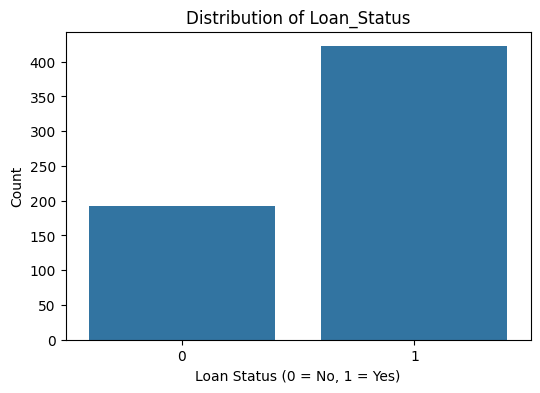

In [ ]:
# Phase 2: Data Exploration (on cleaned training data)
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Summary statistics
print("🔹 Summary statistics:")
display(X_train.describe())

# Step 2: Distribution of target variable
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Distribution of Loan_Status")
plt.xlabel("Loan Status (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

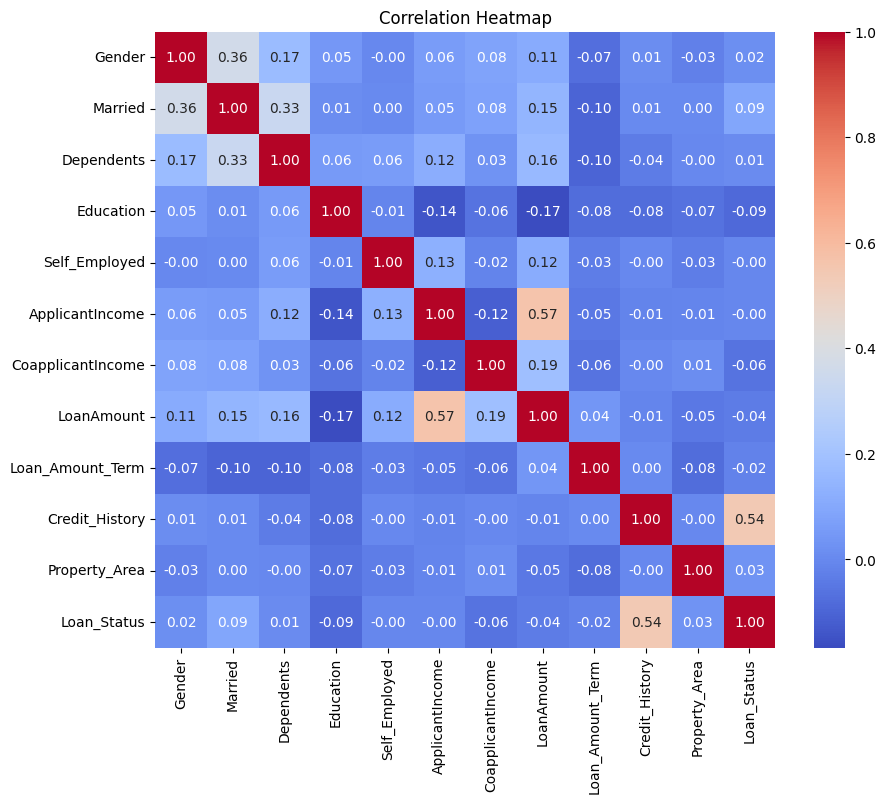

In [ ]:
# Step 3: Correlation heatmap
df_train = X_train.copy()
df_train['Loan_Status'] = y_train

plt.figure(figsize=(10, 8))
sns.heatmap(df_train.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

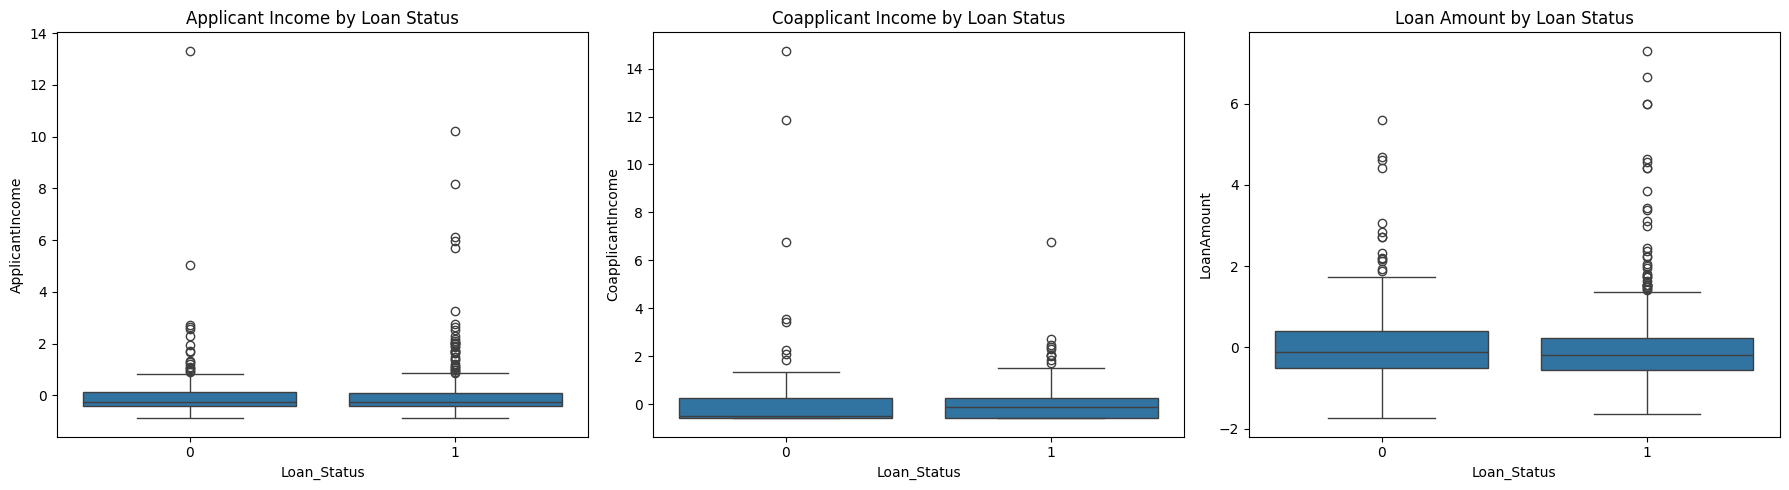

In [ ]:
# Step 4: Box plots of income and loan amount by loan status
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df_train, x='Loan_Status', y='ApplicantIncome', ax=axs[0])
axs[0].set_title("Applicant Income by Loan Status")
sns.boxplot(data=df_train, x='Loan_Status', y='CoapplicantIncome', ax=axs[1])
axs[1].set_title("Coapplicant Income by Loan Status")
sns.boxplot(data=df_train, x='Loan_Status', y='LoanAmount', ax=axs[2])
axs[2].set_title("Loan Amount by Loan Status")
plt.tight_layout()
plt.show()

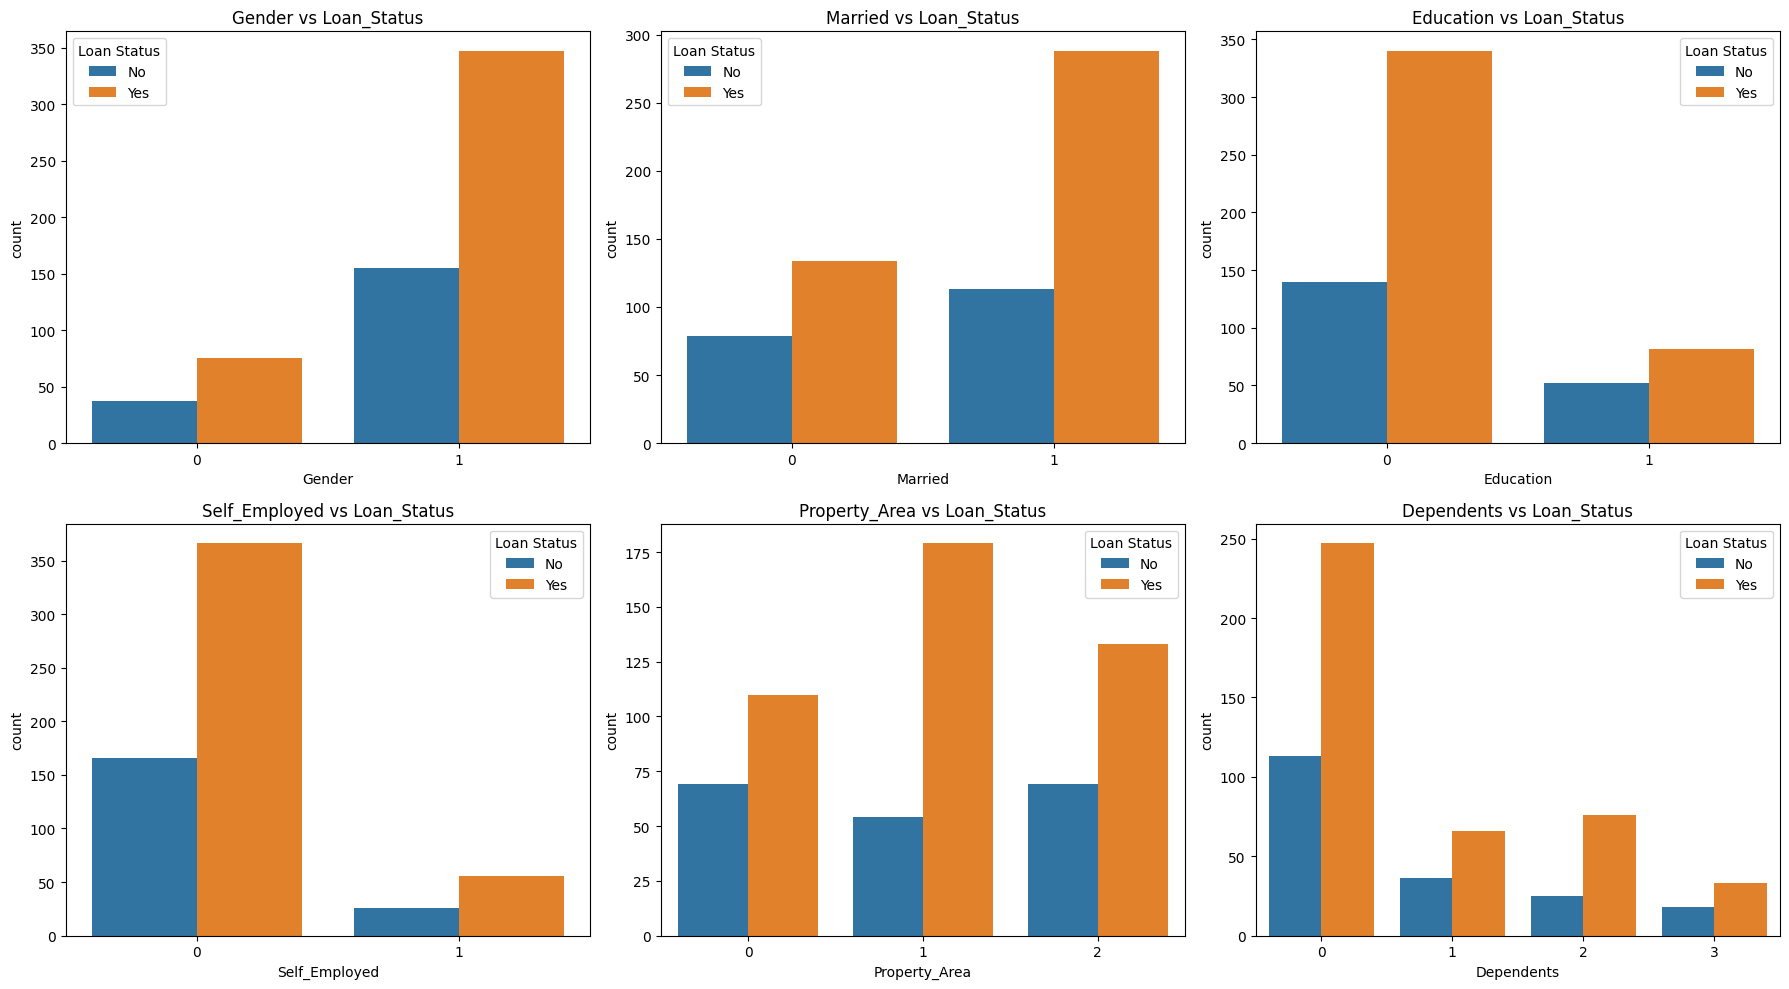

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of categorical columns
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents']

# Create subplots - 2 rows, 3 columns
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()  # Flatten to simplify indexing

# Plot each categorical column
for i, col in enumerate(cat_cols):
    sns.countplot(data=df_train, x=col, hue='Loan_Status', ax=axes[i])
    axes[i].set_title(f"{col} vs Loan_Status")
    axes[i].legend(title="Loan Status", labels=["No", "Yes"])

# Remove unused subplots if any (not needed in this case but useful for dynamic lists)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

# Step 0: Remove invalid labels (keep only 0 and 1)
valid_mask = y_train.isin([0, 1])
X_train = X_train[valid_mask]
y_train = y_train[valid_mask].astype(int)

# Step 1: Split train set into training and validation subsets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Step 2: Define candidate models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (Linear Kernel)": SVC(kernel='linear', probability=True, random_state=42)
}

# Step 3: Train and evaluate each model
results = []

for name, model in models.items():
    model.fit(X_train_split, y_train_split)
    y_pred = model.predict(X_val_split)
    acc = accuracy_score(y_val_split, y_pred)
    f1 = f1_score(y_val_split, y_pred)
    cm = confusion_matrix(y_val_split, y_pred)

    # Collect results
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1 Score': f1
    })

    # Print evaluation metrics
    print(f"\n🔸 {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_val_split, y_pred))

# Step 4: Display summary results as DataFrame
results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
print("\n📊 Summary of Model Performance:\n", results_df)


🔸 Logistic Regression
Accuracy: 0.8618
F1 Score: 0.9081
Confusion Matrix:
 [[22 16]
 [ 1 84]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123


🔸 Decision Tree
Accuracy: 0.7480
F1 Score: 0.8121
Confusion Matrix:
 [[25 13]
 [18 67]]
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.66      0.62        38
           1       0.84      0.79      0.81        85

    accuracy                           0.75       123
   macro avg       0.71      0.72      0.71       123
weighted avg       0.76      0.75      0.75       123


🔸 Random Forest
Accuracy: 0.8374
F1 Score: 0.8876
Confusion Matrix:
 [[24 14]
 [ 6 79]]
Classification Report:
  

/tmp/ipython-input-12-3183771463.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
/tmp/ipython-input-12-3183771463.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)


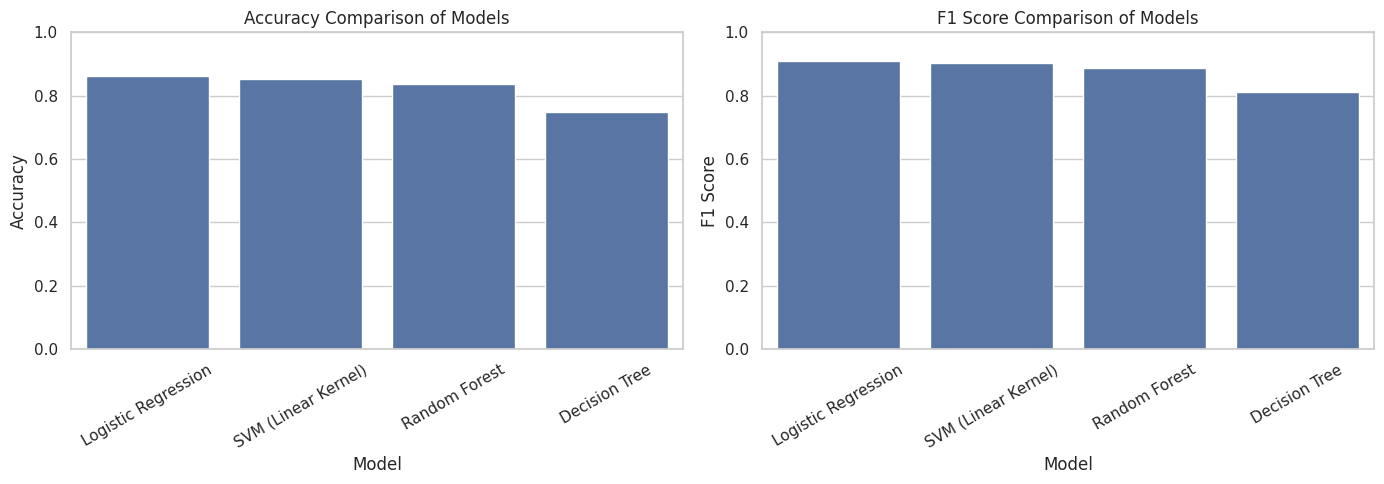

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Barplot for Accuracy
sns.barplot(data=results_df, x='Model', y='Accuracy', ax=axes[0])
axes[0].set_title('Accuracy Comparison of Models')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Accuracy')

# Barplot for F1 Score
sns.barplot(data=results_df, x='Model', y='F1 Score', ax=axes[1])
axes[1].set_title('F1 Score Comparison of Models')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('F1 Score')

plt.tight_layout()
plt.show()

In [ ]:
# Step 4: Train final model on full training set
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

# Step 5: Predict on test data
y_test_pred = best_model.predict(X_test)

# Optional: Save results with Loan_IDs for submission
submission = pd.DataFrame({
    'Loan_ID': test_ids,
    'Loan_Status': ['Y' if pred == 1 else 'N' for pred in y_test_pred]
})

print("\n✅ Sample predictions for test set:")
display(submission.head())


✅ Sample predictions for test set:


,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,N


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=3, sampling_strategy=1.0)
X_train_smote, y_train_smote = smote.fit_resample(X_train_split, y_train_split)

print("Class distribution (after SMOTE on train_split):")
print(pd.Series(y_train_smote).value_counts())

Class distribution (after SMOTE on train_split):
Loan_Status
1    337
0    337
Name: count, dtype: int64


In [ ]:
def evaluate_models(models, X_tr, y_tr, X_val, y_val, tag=""):
    results = []

    for name, model in models.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)  # default: pos_label=1

        cm = confusion_matrix(y_val, y_pred)

        results.append({
            "Setting": tag,
            "Model": name,
            "Accuracy": acc,
            "F1 Score": f1
        })

        print(f"\n🔸 {name} {tag}")
        print(f"Accuracy: {acc:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print("Confusion Matrix:\n", cm)
        print("Classification Report:\n", classification_report(y_val, y_pred))

    return pd.DataFrame(results)

smote_df = evaluate_models(models, X_train_smote, y_train_smote, X_val_split, y_val_split, tag="(SMOTE)")


🔸 Logistic Regression (SMOTE)
Accuracy: 0.7967
F1 Score: 0.8555
Confusion Matrix:
 [[24 14]
 [11 74]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.63      0.66        38
           1       0.84      0.87      0.86        85

    accuracy                           0.80       123
   macro avg       0.76      0.75      0.76       123
weighted avg       0.79      0.80      0.79       123


🔸 Decision Tree (SMOTE)
Accuracy: 0.8049
F1 Score: 0.8537
Confusion Matrix:
 [[29  9]
 [15 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.76      0.71        38
           1       0.89      0.82      0.85        85

    accuracy                           0.80       123
   macro avg       0.77      0.79      0.78       123
weighted avg       0.82      0.80      0.81       123


🔸 Random Forest (SMOTE)
Accuracy: 0.7967
F1 Score: 0.8555
Confusion Matrix:
 [[24 14]
 [11 74]]
C

In [ ]:
combined_results_df = pd.concat([results_df, smote_df], ignore_index=True)
combined_results_df = combined_results_df.sort_values(by=["F1 Score", "Accuracy"], ascending=False)

print("\n📊 Summary of Model Performance (Baseline vs SMOTE):\n")
print(combined_results_df)


📊 Summary of Model Performance (Baseline vs SMOTE):

                 Model  Accuracy  F1 Score  Setting
0  Logistic Regression  0.861789  0.908108      NaN
7  SVM (Linear Kernel)  0.861789  0.908108  (SMOTE)
1  SVM (Linear Kernel)  0.853659  0.903226      NaN
2        Random Forest  0.837398  0.887640      NaN
4  Logistic Regression  0.796748  0.855491  (SMOTE)
6        Random Forest  0.796748  0.855491  (SMOTE)
5        Decision Tree  0.804878  0.853659  (SMOTE)
3        Decision Tree  0.747967  0.812121      NaN


In [ ]:
!pip install pycaret

In [ ]:
import sys, platform
print(platform.platform())
print(sys.executable)
print(sys.version)

Linux-6.6.122+-x86_64-with-glibc2.35
/usr/bin/python3
3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


In [ ]:
from pycaret.classification import *

# Combine X and y
df_train_full = X_train.copy()
df_train_full['Loan_Status'] = y_train

setup(
    data=df_train_full,
    target='Loan_Status',
    session_id=42,
    verbose=False,
    html=False
)

# Compare models
best_model = compare_models()

# Print best model
print("\n✅ Best model according to PyCaret:")
print(best_model)

                                    Model  Accuracy     AUC  Recall   Prec.  \
ridge                    Ridge Classifier    0.7948  0.7030  0.9830  0.7781   
lda          Linear Discriminant Analysis    0.7948  0.7027  0.9830  0.7781   
lr                    Logistic Regression    0.7925  0.7025  0.9797  0.7776   
rf               Random Forest Classifier    0.7759  0.7770  0.9255  0.7875   
nb                            Naive Bayes    0.7690  0.7038  0.9459  0.7714   
ada                  Ada Boost Classifier    0.7690  0.7102  0.9014  0.7926   
gbc          Gradient Boosting Classifier    0.7643  0.7260  0.9120  0.7840   
lightgbm  Light Gradient Boosting Machine    0.7643  0.7536  0.8949  0.7929   
xgboost         Extreme Gradient Boosting    0.7619  0.7397  0.8710  0.8027   
qda       Quadratic Discriminant Analysis    0.7550  0.6964  0.9218  0.7690   
et                 Extra Trees Classifier    0.7434  0.7450  0.8674  0.7835   
dt               Decision Tree Classifier    0.6967 

In [ ]:
models_to_test = ['rf']
# models_to_test = ['ridge', 'lr', 'rf', 'xgboost']

tuned_models = {}

for m in models_to_test:

    # 1. Create original model
    base = create_model(m)

    # 2. Show parameters BEFORE tuning
    print("\n" + "=" * 60)
    print(f"MODEL: {m}")
    print("=" * 60)

    print("\nParameters BEFORE tuning:")
    for param, value in base.get_params().items():
        print(f"{param}: {value}")

    print("\n" + "-" * 60)
    print("START HYPERPARAMETER TUNING")
    print("-" * 60)

    # 3. Tune model
    # PyCaret will display the 10-fold results after this point
    tuned = tune_model(
        base,
        optimize='AUC'
    )

    tuned_models[m] = tuned

# Get latest result table
tuned_results = pull()

      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.8140  0.8436  0.9333  0.8235  0.8750  0.5169  0.5326
1       0.7442  0.6936  0.9000  0.7714  0.8308  0.3194  0.3359
2       0.8140  0.8372  0.9000  0.8438  0.8710  0.5389  0.5425
3       0.7907  0.8231  1.0000  0.7692  0.8696  0.3828  0.4865
4       0.7442  0.8487  0.8667  0.7879  0.8254  0.3512  0.3568
5       0.8372  0.8017  0.9655  0.8235  0.8889  0.5916  0.6185
6       0.8372  0.9064  0.9655  0.8235  0.8889  0.5916  0.6185
7       0.7674  0.7241  0.9655  0.7568  0.8485  0.3786  0.4363
8       0.7674  0.7303  0.9655  0.7568  0.8485  0.3786  0.4363
9       0.6429  0.5610  0.7931  0.7188  0.7541  0.1076  0.1094
Mean    0.7759  0.7770  0.9255  0.7875  0.8501  0.4157  0.4473
Std     0.0552  0.0955  0.0586  0.0378  0.0383  0.1412  0.1454

MODEL: rf

Parameters BEFORE tuning:
bootstrap: True
ccp_alpha: 0.0
class_weight: None
criterion: gini
max_depth: Non

Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.8372  0.8667  1.0000  0.8108  0.8955  0.5446  0.6117
1       0.7674  0.7154  0.9667  0.7632  0.8529  0.3323  0.3931
2       0.8140  0.7436  0.9667  0.8056  0.8788  0.4926  0.5327
3       0.7907  0.7897  1.0000  0.7692  0.8696  0.3828  0.4865
4       0.8372  0.8795  1.0000  0.8108  0.8955  0.5446  0.6117
5       0.8140  0.7537  1.0000  0.7838  0.8788  0.5029  0.5796
6       0.8140  0.8768  0.9655  0.8000  0.8750  0.5235  0.5606
7       0.7674  0.6946  1.0000  0.7436  0.8529  0.3505  0.4609
8       0.7209  0.6847  0.9655  0.7179  0.8235  0.2205  0.2901
9       0.7619  0.5570  0.9655  0.7568  0.8485  0.3291  0.3900
Mean    0.7925  0.7562  0.9830  0.7762  0.8671  0.4223  0.4917
Std     0.0356  0.0967  0.0170  

In [ ]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
import joblib
joblib.dump(best_model, 'loan_approval_model.pkl')

['loan_approval_model.pkl']

In [ ]:
!pip install gradio

In [ ]:
code = """
import gradio as gr
import pandas as pd
import joblib

model = joblib.load("loan_approval_model.pkl")

# LabelEncoder-like mappings (must match your training phase!)
gender_map = {'Male': 1, 'Female': 0}
married_map = {'Yes': 1, 'No': 0}
dependents_map = {'0': 0, '1': 1, '2': 2, '3+': 3}
education_map = {'Graduate': 1, 'Not Graduate': 0}
self_employed_map = {'Yes': 1, 'No': 0}
property_area_map = {'Urban': 2, 'Rural': 0, 'Semiurban': 1}

def predict_loan(gender, married, dependents, education, self_employed,
                 applicant_income, coapplicant_income, loan_amount,
                 loan_term, credit_history, property_area):

    gender = gender_map[gender]
    married = married_map[married]
    dependents = dependents_map[dependents]
    education = education_map[education]
    self_employed = self_employed_map[self_employed]
    property_area = property_area_map[property_area]

    df = pd.DataFrame({
        'Gender': [gender],
        'Married': [married],
        'Dependents': [dependents],
        'Education': [education],
        'Self_Employed': [self_employed],
        'ApplicantIncome': [applicant_income],
        'CoapplicantIncome': [coapplicant_income],
        'LoanAmount': [loan_amount],
        'Loan_Amount_Term': [loan_term],
        'Credit_History': [credit_history],
        'Property_Area': [property_area]
    })
    result = model.predict(df)[0]
    return "✅ Approved" if result == 1 else "❌ Rejected"

inputs = [
    gr.Radio(["Male", "Female"], label="Gender"),                     # Label encoded
    gr.Radio(["Yes", "No"], label="Married"),                         # Label encoded
    gr.Radio(["0", "1", "2", "3+"], label="Dependents"),              # Label encoded
    gr.Radio(["Graduate", "Not Graduate"], label="Education"),        # Label encoded
    gr.Radio(["Yes", "No"], label="Self Employed"),                   # Label encoded
    gr.Number(label="Applicant Income", precision=0),                 # StandardScaler
    gr.Number(label="Coapplicant Income", precision=0),              # StandardScaler
    gr.Number(label="Loan Amount", precision=0),                     # StandardScaler
    gr.Dropdown([12, 36, 60, 84, 120, 180, 240, 300, 360, 480],
                label="Loan Amount Term"),                            # Numerical
    gr.Radio([1.0, 0.0], label="Credit History"),                     # Numerical
    gr.Radio(["Urban", "Rural", "Semiurban"], label="Property Area") # Label encoded
]

iface = gr.Interface(fn=predict_loan, inputs=inputs, outputs="text", title="Loan Approval Predictor")
iface.launch(share=True)
"""

with open("app_gradio.py", "w") as f:
    f.write(code)

In [ ]:
!python app_gradio.py

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a852c6fbf6e236be40.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
